In [1]:
import sympy as sym
sym.init_printing()

In [2]:
def smult(s,lst):
    temp = [s*term for term in lst]
    return [term for term in map(sym.simplify,temp)]
    
def vadd(lst1,lst2):
    temp = [term1+term2 for term1,term2 in zip(lst1,lst2)]
    return [term for term in map(sym.simplify,temp)]
    
def vdot(lst1,lst2):
    temp = sum( comp1*comp2 for comp1,comp2 in zip(lst1,lst2) )
    return sym.simplify(temp)

def vmag(lst):
    return sym.sqrt(vdot(lst,lst))

def vcross(lst1,lst2):
    temp    = [0,0,0]
    temp[0] = lst1[1]*lst2[2] - lst1[2]*lst2[1]
    temp[1] = lst1[2]*lst2[0] - lst1[0]*lst2[2]
    temp[2] = lst1[0]*lst2[1] - lst1[1]*lst2[0]
    return [term for term in map(sym.simplify,temp)]

def convert_frame(lst,frame):
    x_hat   = frame[0]
    y_hat   = frame[1]
    z_hat   = frame[2]
    temp    = [0,0,0]
    temp[0] = vdot(lst,x_hat)
    temp[1] = vdot(lst,y_hat)
    temp[2] = vdot(lst,z_hat)
    return [term for term in map(sym.simplify,temp)]

def filter_sum(expr,symbol_keep,symbol_exclude):
    filter_part = sum(
    term for term in expr.as_ordered_terms()
    if term.has(*symbol_keep) and not term.has(*symbol_exclude))
    return filter_part

def numerator(expr):
    num, _ = sym.fraction(expr)
    return num

# Allocate all the symbols needed

In [3]:
mu         = sym.Symbol('mu')
t          = sym.Symbol('t')
rho1       = sym.Symbol('rho_1')
rho2       = sym.Symbol('rho_2')
X, Y, Z    = sym.symbols('X Y Z')
X1, Y1, Z1 = sym.symbols('X1 Y1 Z1')
X2, Y2, Z2 = sym.symbols('X2 Y2 Z2')
x, y, z    = sym.symbols('x y z')
x1, y1, z1 = sym.symbols('x1 y1 z1')
x2, y2, z2 = sym.symbols('x2 y2 z2')
xf         = sym.Function('x')
yf         = sym.Function('y')
zf         = sym.Function('z')
d1, d2     = sym.symbols('d1 d2')

# Inertial Formulation

## &nbsp;&nbsp;&nbsp;&nbsp; Define Primary/Secondary Physical Parameters

In [4]:
#mass and distance based on non-dimensional form
m1 = (1-mu)
m2 = mu
rho1 = -mu
rho2 = (1-mu)
#positions under the circular motion assumptions
X1 = rho1*sym.cos(t)
Y1 = rho1*sym.sin(t)
Z1 = 0
X2 = rho2*sym.cos(t)
Y2 = rho2*sym.sin(t)
Z2 = 0

## &nbsp;&nbsp;&nbsp;&nbsp; Define the inertial position vectors and confirm COM is at origin

In [5]:
R_I  = [X,Y,Z]
R1_I = [X1,Y1,Z1]
R2_I = [X2,Y2,Z2]

## &nbsp;&nbsp;&nbsp;&nbsp; Confirm (as a check) that the COM is at the origin

In [6]:
COM = vadd(smult(m1,R1_I),smult(m2,R2_I))
COM

## &nbsp;&nbsp;&nbsp;&nbsp; Find the relative position vectors from the massives to the restricted

In [7]:
R_r1_I = vadd(R_I,smult(-1,R1_I))
R_r2_I = vadd(R_I,smult(-1,R2_I))
R_r1_I, R_r2_I

## &nbsp;&nbsp;&nbsp;&nbsp; Find the distances between the massives and the restricted - inertial

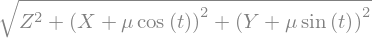

In [8]:
D1 = vmag(R_r1_I)
D1

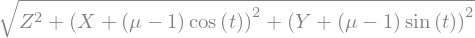

In [9]:
D2 = vmag(R_r2_I)
D2

## &nbsp;&nbsp;&nbsp;&nbsp; Construct the right-hand sides of the equations of motion

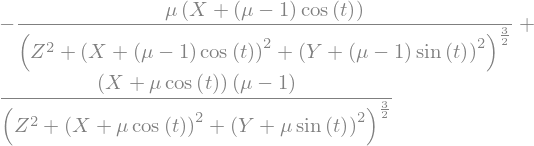

In [10]:
fX = -m1*R_r1_I[0]/D1**3 - m2*R_r2_I[0]/D2**3
fX

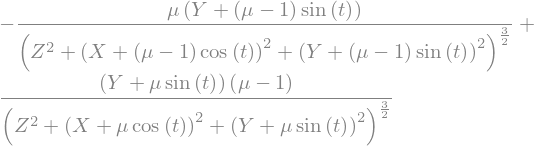

In [11]:
fY = -m1*R_r1_I[1]/D1**3 - m2*R_r2_I[1]/D2**3
fY

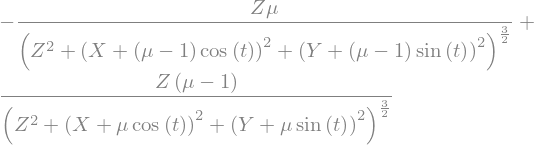

In [12]:
fZ = -m1*R_r1_I[2]/D1**3 - m2*R_r2_I[2]/D2**3
fZ

# Define the inertial and corotating coordinate systems and the transformations between them

## &nbsp;&nbsp;&nbsp;&nbsp; Express all vectors in terms in the inertial system

In [13]:
X_hat_I = [1,0,0]
Y_hat_I = [0,1,0]
Z_hat_I = [0,0,1]
x_hat_I = vadd(R2_I,smult(-1,R1_I))
z_hat_I = [0,0,1]
y_hat_I = vcross(z_hat_I,x_hat_I)

In [14]:
x_hat_I, y_hat_I, z_hat_I

## &nbsp;&nbsp;&nbsp;&nbsp; Express all the vectors in the co-rotating system

This step is done by using a frame invariant method.  Consider the position vector of the restricted body ${\vec R}$.  Given that we know it in the inertial frame in terms of its components $\{ X, Y, Z \}$ (which are measured) and its fundamental basis vectors $\{ {\hat X},{\hat Y}.{\hat Z} \}$ (which are defined by the measurements or in such a way as to give the measurements meaning) we can express ${\vec R} = X {\hat X} + Y {\hat Y} + Z {\hat Z}$. 

We also can express the basis vectors of the rotating frame in the inertial system.  For example ${\hat x} = \cos t {\hat X} + \sin t {\hat Y}$. Combining these two ideas we can express ${\vec R} = x(X,Y,Z) {\hat x}(X,Y,Z) + y(X,Y,Z) {\hat y}(X,Y,Z) + z(X,Y,Z) {\hat z}(X,Y,Z)$ where we find the $\{{\hat x},{\hat y},{\hat z}\}(X,Y,Z)$ and $\{x,y,z\}(X,Y,Z)$ each separately.

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Expressing the basis vectors in the co-rotating system
Expressing the basis vectors is done with a call to convert_frame(), which projects an inertial vector (via dot products) along each of the inertial expressions for the rotating-frame basis vectors.  For example, ${\vec X} \cdot {\hat x}$ gives the x-component of that vector, denoted by $[{\vec X}]_x$ in the co-rotating frame.  Since it isn't possible to specify the system when the components are stored in a list, the list name is decorated with a 'rot'.


### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Expressing the components in the co-rotating system
To express the components of ${\vec R}$ in $\{x,y,z\}$ we first have to discover how they are defined in terms of the inertial measurments and then invert the relationship to express $X(x,y,z)$, etc..  The only vector for which this occurs is ${\vec R}$.  By converting it into the co-rotating systen and then examing the components we find (see below):

$$ x = {\vec R} \cdot {\hat x} = X \cos (t) + Y \sin (t) $$
and
$$ y = {\vec R} \cdot {\hat y} = -X \sin (t) + Y \cos (t) $$

Inverting these we can substitute
$$ X \rightarrow x \cos (t) - y \sin(t)$$
and
$$ Y \rightarrow x \sin (t) + y \cos(t)$$

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3.2.2.a Check on conversion
As a check, we expect to see ${\hat x}$, ${\hat y}$, and ${\hat z}$ as being represented by the lists [1,0,0], [0,1,0], and [0,0,1] in this frame and that ${\vec R}_1 = [-\mu,0,0]$ and ${\vec R}_2 = [1-\mu,0,0]$.


In [15]:
rot_frame_I = [x_hat_I,y_hat_I,z_hat_I]
x_hat_rot = convert_frame(x_hat_I,rot_frame_I)
y_hat_rot = convert_frame(y_hat_I,rot_frame_I)
z_hat_rot = convert_frame(z_hat_I,rot_frame_I)
X_hat_rot = convert_frame(X_hat_I,rot_frame_I)
Y_hat_rot = convert_frame(Y_hat_I,rot_frame_I)
Z_hat_rot = convert_frame(Z_hat_I,rot_frame_I)

In [16]:
x_hat_rot, y_hat_rot, z_hat_rot

In [17]:
X_hat_rot, Y_hat_rot, Z_hat_rot

In [18]:
R_rot  = convert_frame(R_I, rot_frame_I)
R1_rot = convert_frame(R1_I,rot_frame_I)
R2_rot = convert_frame(R2_I,rot_frame_I)
R1_rot, R2_rot

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3.2.2.b Solving to get $X(x,y)$ and $Y(x,y)$

By construction, $\left[ {\vec R} \right]_{rot} = [x,y,z]$ but since we started in the inertial frame these components are defined in terms of what is observed in the inertial frame ($X$, $Y$, and $Z$). So, we need to invert these linear relationships so as to know how to relate what is observed in the inertial frame to that which is observed in the co-rotating frame -- in other words to eliminate $X$, $Y$, and $Z$. 

In [19]:
R_rot

In [20]:
conv1 = x - R_rot[0]
conv2 = y - R_rot[1]
conv1,conv2

In [21]:
solns = sym.solve([conv1,conv2],(X,Y),simplify=True)
solns

In [22]:
X_subs  =  solns[X]
Y_subs  =  solns[Y]
Z_subs  = z
I_to_R  = {X:x*sym.cos(t) - y*sym.sin(t),Y:x*sym.sin(t)+y*sym.cos(t),Z:z}

In [23]:
r_rot  = [sym.simplify(sym.expand(term.subs(I_to_R))) for term in R_rot]
r1_rot = [sym.simplify(sym.expand(term.subs(I_to_R))) for term in R1_rot]
r2_rot = [sym.simplify(sym.expand(term.subs(I_to_R))) for term in R2_rot]
r_rot, r1_rot, r2_rot

# Co-Rotating Formulation

## &nbsp;&nbsp;&nbsp;&nbsp; Physical Parameters Already Allocated

## &nbsp;&nbsp;&nbsp;&nbsp; Position Vectors Already Determined Above

## &nbsp;&nbsp;&nbsp;&nbsp; Convert the time derivatives on the LHS

In [24]:
Xt = xf(t)*sym.cos(t) - yf(t)*sym.sin(t)
Yt = xf(t)*sym.sin(t) + yf(t)*sym.cos(t)

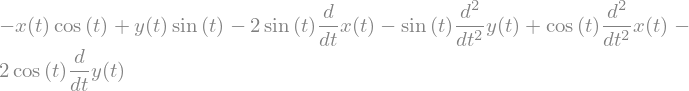

In [25]:
LHS_X = sym.diff(Xt,t,2)
LHS_X

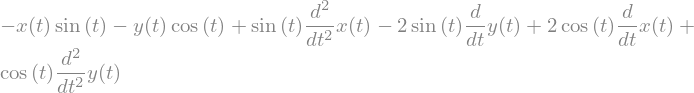

In [26]:
LHS_Y = sym.diff(Yt,t,2)
LHS_Y

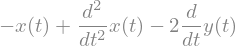

In [27]:
LHS_x = LHS_X*sym.cos(t) + LHS_Y*sym.sin(t)
LHS_x = sym.simplify(LHS_x)
LHS_x

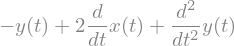

In [28]:
LHS_y = -LHS_X*sym.sin(t) + LHS_Y*sym.cos(t)
LHS_y = sym.simplify(LHS_y)
LHS_y

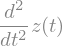

In [45]:
LHS_z = sym.diff(zf(t),t,2)
LHS_z

## &nbsp;&nbsp;&nbsp;&nbsp; Compute the RHS (same transformation)

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  Convert the distances

Since they only depend on the instantaneous geometry use ${\vec R}-{\vec R}_1$ either: 1) expressed in inertial and then convert to the rotating coordinates or 2) in rotating coordinates to begin with.  They both produce the same result.

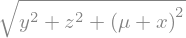

In [29]:
D1_rot = vmag(vadd(R_rot,smult(-1,R1_rot)))
D1_sq = sym.simplify(sym.expand((D1_rot**2).subs(I_to_R)))
x_mu_poly = filter_sum(D1_sq,(x,mu),(y,z))
rest = D1_sq - x_mu_poly
x_mu_poly = sym.factor(x_mu_poly)
D1_rot = sym.sqrt(x_mu_poly+rest)
D1_rot

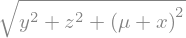

In [30]:
D1_rot = vmag(vadd(r_rot,smult(-1,r1_rot)))
D1_rot

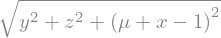

In [31]:
D2_rot = vmag(vadd(R_rot,smult(-1,R2_rot)))
D2_sq = sym.simplify(sym.expand((D2_rot**2).subs(I_to_R)))
x_mu_poly = filter_sum(D2_sq,(x,mu,1),(y,z))
rest = D2_sq - x_mu_poly
x_mu_poly = sym.factor(x_mu_poly)
D2_rot = sym.sqrt(x_mu_poly+rest)
D2_rot

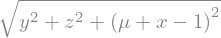

In [32]:
D2_rot = vmag(vadd(r_rot,smult(-1,r2_rot)))
D2_rot

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  Convert the specific forces

To keep expression swell down to a minimum, first substitute the 'co-rotating' distance in place of the inertial one.

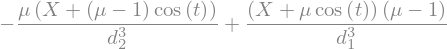

In [33]:
fX = fX.subs({D1:d1,D2:d2})
fX

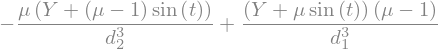

In [34]:
fY = fY.subs({D1:d1,D2:d2})
fY

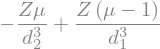

In [40]:
fZ = fZ.subs({D1:d1,D2:d2})
fZ

Tackling this directly doesn't work very well because SymPy wants to combine everything. 

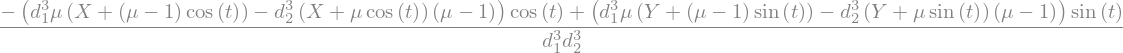

In [35]:
fx = fX*sym.cos(t) - fY*sym.sin(t)
fx = sym.simplify(fx)
fx

Separate out numerators.

In [36]:
fXn1 = numerator(fX.args[0])
fXn2 = numerator(fX.args[1])
fYn1 = numerator(fY.args[0])
fYn2 = numerator(fY.args[1])
fXn1, fXn2, fYn1, fYn2

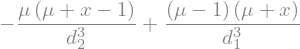

In [37]:
#linear combination for x
#primary
fxn1 = fXn1*sym.cos(t) + fYn1*sym.sin(t)
fxn1 = sym.simplify(sym.expand(fxn1.subs(I_to_R)))
fxn1 = sym.factor(fxn1)
#secondary
fxn2 = fXn2*sym.cos(t) + fYn2*sym.sin(t)
fxn2 = sym.simplify(sym.expand(fxn2.subs(I_to_R)))
fxn2 = sym.factor(fxn2)
fxn2
fx   = fxn1/d1**3 + fxn2/d2**3
fx

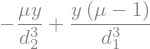

In [38]:
#linear combination for y
#primary
fyn1 = -fXn1*sym.sin(t) + fYn1*sym.cos(t)
fyn1 = sym.simplify(sym.expand(fyn1.subs(I_to_R)))
fyn1 = sym.factor(fyn1)
#secondary
fyn2 = -fXn2*sym.sin(t) + fYn2*sym.cos(t)
fyn2 = sym.simplify(sym.expand(fyn2.subs(I_to_R)))
fyn2 = sym.factor(fyn2)
fyn2
fy   = fyn1/d1**3 + fyn2/d2**3
fy

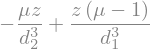

In [47]:
fz = fZ.subs(Z,z)
fz

In [53]:
EOMx = sym.Eq(LHS_x,fx)
EOMy = sym.Eq(LHS_y,fy)
EOMz = sym.Eq(LHS_z,fz)
Denom1 = sym.Eq(d1,D1_rot)
Denom2 = sym.Eq(d2,D2_rot)

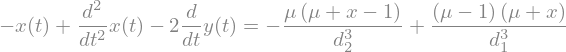

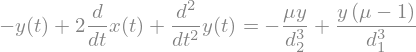

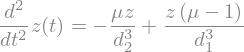

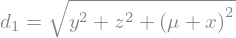

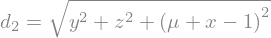

In [54]:
from IPython.display import display
display(EOMx)
display(EOMy)
display(EOMz)
display()
display(Denom1)
display(Denom2)

# Same (up to placement of a minus sign and cosmetic reordering) as this image adapted from A. E. Roy:

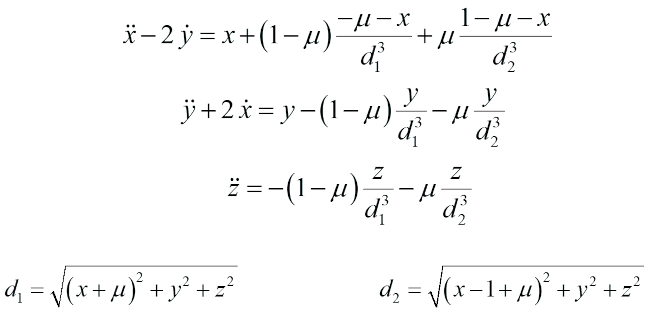